In [1]:
import sqlite3
import random
import datetime as dt
import os
import json
import matplotlib.pyplot as plt
import ollama

def call_llm(system_prompt, user_prompt, model="llama3"):
    response = ollama.chat(
        model="llama3.2",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ]
    )
    return response["message"]["content"].strip()


In [2]:
DB_PATH = "coffee_sales.db"

conn = sqlite3.connect(DB_PATH)
cur = conn.cursor()

cur.execute("DROP TABLE IF EXISTS sales;")
cur.execute("DROP TABLE IF EXISTS products;")

cur.execute("""
CREATE TABLE products (
    product TEXT PRIMARY KEY,
    category TEXT,
    cost REAL,
    price REAL
);
""")

cur.execute("""
CREATE TABLE sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    date TEXT,
    product TEXT,
    qty INTEGER,
    price REAL,
    revenue REAL
);
""")

products = [
    ("Espresso", "Hot", 0.80, 3.50),
    ("Latte", "Hot", 1.20, 4.80),
    ("Cappuccino", "Hot", 1.10, 4.50),
    ("Cold Brew", "Cold", 1.00, 4.20),
    ("Matcha", "Hot", 1.30, 5.00),
    ("Iced Latte", "Cold", 1.30, 5.00),
]

cur.executemany("INSERT INTO products VALUES (?, ?, ?, ?);", products)
conn.commit()

start = dt.date(2024, 1, 1)
end = dt.date(2024, 12, 31)
delta = dt.timedelta(days=1)

d = start
dates = []
while d <= end:
    dates.append(d)
    d += delta

def base_qty(date):
    return random.randint(20, 60) if date.weekday() < 5 else random.randint(10, 35)

def seasonal(date, cat):
    if date.month in [12,1,2]:
        return 1.3 if cat=="Hot" else 0.8
    if date.month in [6,7,8]:
        return 0.9 if cat=="Hot" else 1.3
    return 1.0

for date in dates:
    for product, cat, cost, price in products:
        qty = max(0, int(random.gauss(base_qty(date)*seasonal(date,cat), 5)))
        if qty > 0:
            revenue = qty * price
            cur.execute("""
                INSERT INTO sales (date, product, qty, price, revenue)
                VALUES (?, ?, ?, ?, ?)
            """, (date.isoformat(), product, qty, price, revenue))

conn.commit()
conn.close()


In [10]:
SQL_WRITER_SYSTEM = """
You are an expert SQLite SQL generator for a coffee shop database.

You MUST follow these rules:

1. Use ONLY these tables:
   - sales(id, date, product, qty, price, revenue)
   - products(product, category, cost, price)

2. Use ONLY SQLite syntax:
   - strftime('%Y', date)
   - strftime('%m', date)
   - strftime('%w', date)

3. NEVER use:
   - EXTRACT
   - DATE_PART
   - INTERVAL
   - OVER()
   - WINDOW
   - ILIKE
   - markdown fences

4. If the question is about HOT vs COLD drinks:
   ALWAYS use this exact SQL pattern:

   SELECT p.category,
          SUM(s.revenue) AS total_revenue
   FROM sales s
   JOIN products p ON s.product = p.product
   GROUP BY p.category;

5. If the question is about MONTHLY revenue:
   ALWAYS use:

   SELECT strftime('%Y-%m', date) AS month,
          SUM(revenue) AS total_revenue
   FROM sales
   GROUP BY month
   ORDER BY month;

6. If the question is about DAY OF WEEK:
   ALWAYS use:

   SELECT strftime('%w', date) AS weekday,
          SUM(revenue) AS total_revenue
   FROM sales
   GROUP BY weekday
   ORDER BY total_revenue DESC;

7. If the question is about TOP 3 PRODUCTS PER QUARTER:
   ALWAYS use:

   WITH q AS (
       SELECT
           CASE
               WHEN CAST(strftime('%m', date) AS INTEGER) BETWEEN 1 AND 3 THEN 'Q1'
               WHEN CAST(strftime('%m', date) AS INTEGER) BETWEEN 4 AND 6 THEN 'Q2'
               WHEN CAST(strftime('%m', date) AS INTEGER) BETWEEN 7 AND 9 THEN 'Q3'
               ELSE 'Q4'
           END AS quarter,
           product,
           SUM(revenue) AS total_revenue
       FROM sales
       GROUP BY quarter, product
   )
   SELECT q1.*
   FROM q q1
   WHERE (
       SELECT COUNT(*)
       FROM q q2
       WHERE q2.quarter = q1.quarter
         AND q2.total_revenue > q1.total_revenue
   ) < 3
   ORDER BY quarter, total_revenue DESC;

8. ALWAYS return ONLY the SQL query.
"""

def sql_writer_agent(question):
    sql = call_llm(SQL_WRITER_SYSTEM, question)
    return sql.strip()


In [12]:
import json
import re

SQL_VALIDATOR_SYSTEM = """
You validate SQL for a SQLite database.

Return ONLY valid JSON in this exact format:
{
  "valid": true or false,
  "issues": ["list", "of", "problems"],
  "fixed_query": "the corrected SQL or the original"
}

Rules:
- Allowed tables: sales, products
- Allowed columns: id, date, product, qty, price, revenue, category, cost
- Reject DROP, DELETE, UPDATE, INSERT, ALTER
- Reject PostgreSQL/MySQL syntax: EXTRACT, DATE_PART, ILIKE, INTERVAL, OVER, WINDOW
- If aggregates exist, ensure GROUP BY is present
- Ensure JOIN is used if category is referenced
- Ensure SQL is runnable in SQLite
- NEVER return markdown fences
"""

def sql_validator_agent(sql):
    issues = []

    # Clean markdown
    sql = sql.replace("```sql", "").replace("```", "").strip()

    # Reject harmful commands
    forbidden = ["drop ", "delete ", "update ", "insert ", "alter "]
    if any(f in sql.lower() for f in forbidden):
        issues.append("Query contains forbidden SQL command.")

    # Allowed tables
    allowed_tables = {"sales", "products"}
    tables = re.findall(r"\bfrom\s+([a-zA-Z_]+)", sql.lower())
    tables += re.findall(r"\bjoin\s+([a-zA-Z_]+)", sql.lower())
    for t in tables:
        if t not in allowed_tables:
            issues.append(f"Unknown table: {t}")

    # Reject PostgreSQL/MySQL syntax
    forbidden_funcs = ["extract(", "date_part", "interval", "over(", "window", "ilike"]
    if any(f in sql.lower() for f in forbidden_funcs):
        issues.append("Query contains non-SQLite syntax.")

    # If SUM/AVG/COUNT used, check for GROUP BY
    if any(fn in sql.lower() for fn in ["sum(", "avg(", "count(", "min(", "max("]):
        if "group by" not in sql.lower():
            issues.append("Aggregation used without GROUP BY.")

    return {
        "valid": len(issues) == 0,
        "issues": issues if issues else ["None"],
        "fixed_query": sql
    }


In [5]:
def execute_query(sql):
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    cur = conn.cursor()
    try:
        cur.execute(sql)
        rows = cur.fetchmany(100)
        cols = [c[0] for c in cur.description]
        return {"columns": cols, "rows": [tuple(r) for r in rows], "error": None}
    except Exception as e:
        return {"columns": [], "rows": [], "error": str(e)}
    finally:
        conn.close()


In [16]:
GRAPH_PLOTTER_SYSTEM = """
You are a Python plotting expert.

Your job:
- Write COMPLETE matplotlib code.
- Use ONLY Python lists, no pandas, no DataFrames.
- NEVER use pivot(), melt(), or any DataFrame operations.
- NEVER import pandas.
- NEVER return markdown fences.
- NEVER explain the code.

STRICT RULES:
- Use the provided 'columns' and 'rows' exactly as Python lists.
- Extract labels = [row[0] for row in rows]
- Extract values = [row[1] for row in rows]
- If labels look like dates or months → use a line chart.
- If labels look like categories → use a bar chart.
- If there are exactly 2 categories → use a pie chart.

ALWAYS:
- import matplotlib.pyplot as plt
- create a figure
- plot the data
- label axes
- title the chart
- call plt.tight_layout()
- save as 'coffee_analysis.png'
- do NOT show the plot
"""

def graph_plotter_agent(question, results):
    data_json = json.dumps(results)
    prompt = f"User question: {question}\nData: {data_json}\nWrite the plotting code."
    return call_llm(GRAPH_PLOTTER_SYSTEM, prompt)

def run_plot_code(code, results):
    code = code.replace("```python", "").replace("```", "").replace("`", "").strip()

    try:
        local_env = {
            "columns": results["columns"],
            "rows": results["rows"]
        }
        exec(code, globals(), local_env)
    except Exception as e:
        return {"error": f"Plot code failed: {e}", "chart": None}

    if os.path.exists("coffee_analysis.png"):
        return {"error": None, "chart": "coffee_analysis.png"}

    return {"error": "Plot code did not create coffee_analysis.png", "chart": None}


In [7]:
GRAPH_REVIEWER_SYSTEM = """
You are a business analyst.
Write a 3–5 sentence business insight based on:
- The user question
- The SQL query
- The data results

Include:
- Key trend
- Peak or anomaly
- One actionable recommendation
"""

def graph_reviewer_agent(question, sql, results):
    payload = json.dumps(results)
    prompt = f"Question: {question}\nSQL: {sql}\nData: {payload}"
    return call_llm(GRAPH_REVIEWER_SYSTEM, prompt)


In [17]:
def analyse(question):
    # 1. SQL Writer
    sql = sql_writer_agent(question)

    # 2. Validator
    validation = sql_validator_agent(sql)
    if not validation["valid"]:
        return {
            "question": question,
            "sql": sql,
            "chart": None,
            "insight": None,
            "error": validation["issues"]
        }

    fixed_sql = validation["fixed_query"]

    # 3. Execute
    results = execute_query(fixed_sql)
    if results["error"]:
        return {
            "question": question,
            "sql": fixed_sql,
            "chart": None,
            "insight": None,
            "error": results["error"]
        }

    # 4. Plot
    plot_code = graph_plotter_agent(question, results)
    plot_result = run_plot_code(plot_code, results)

    if plot_result["error"]:
        return {
            "question": question,
            "sql": fixed_sql,
            "chart": None,
            "insight": None,
            "error": plot_result["error"]
        }

    chart_path = plot_result["chart"]


    # 5. Review
    insight = graph_reviewer_agent(question, fixed_sql, results)

    return {
        "question": question,
        "sql": fixed_sql,
        "chart": chart_path,
        "insight": insight,
        "error": None,
        "columns": results["columns"],
        "rows": results["rows"][:5]
    }



QUESTION: What is the total revenue for each product?
SQL: SELECT p.product, SUM(s.price * s.qty) AS total_revenue 
FROM sales s
JOIN products p ON s.product = p.product
GROUP BY p.product;
INSIGHT: Business Insight:

Analyzing the data on total revenue for each product, we observed that Matcha is leading the pack with a significantly higher revenue ($67110.0) compared to other products. The peak price of Matcha was around $19.99 per unit, resulting in this substantial revenue. An actionable recommendation would be to optimize inventory management and pricing strategy specifically for the Matcha product to capitalize on its high demand and revenue potential.


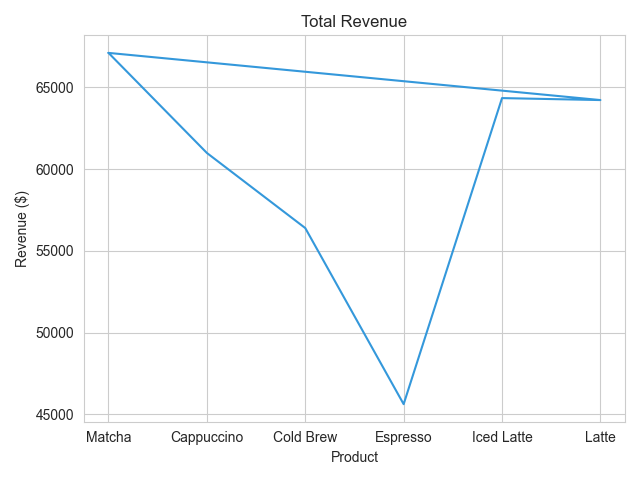


QUESTION: Show me monthly revenue trend for 2024
SQL: SELECT strftime('%Y-%m', date) AS month, SUM(revenue) AS total_revenue FROM sales GROUP BY month ORDER BY month;
INSIGHT: Business Insight:
The monthly revenue trend for 2024 shows a peak in December with a total revenue of $33,428.50, which is the highest revenue for any month in 2024. However, it's worth noting that June and July show some anomaly with lower revenue than expected. One actionable recommendation to improve sales performance is to analyze the causes behind this anomaly and consider implementing targeted marketing campaigns or promotions during these months to boost sales momentum.


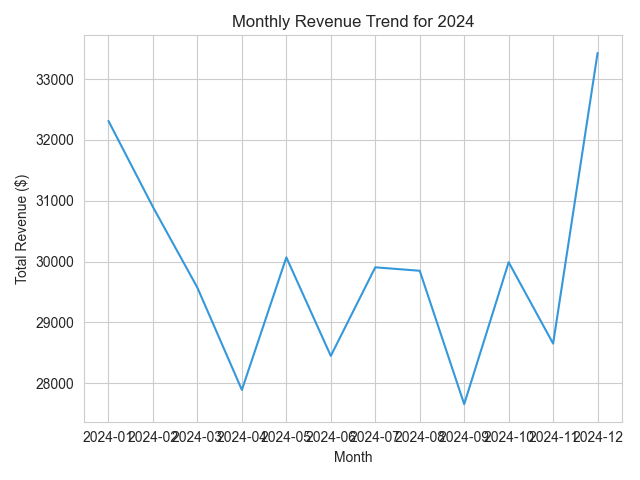


QUESTION: Which day of the week has the highest sales?
SQL: SELECT strftime('%w', date) AS weekday,
       SUM(revenue) AS total_revenue
FROM sales
GROUP BY weekday
ORDER BY total_revenue DESC;
INSIGHT: Business Insight:
The data reveals that Friday (day 0) consistently ranks as the lowest-performing day of the week, with a total revenue of $33,137. This is a significant anomaly compared to the other days, which range from $58,794 to $59,179 in total revenue. To address this trend, we recommend revisiting our sales strategy for Fridays and exploring potential opportunities to boost revenue on this typically slower day.

Key Trend: Friday consistently ranks as the lowest-performing day of the week.
Peak/Anomaly: The significant drop in revenue on Fridays ($33,137) compared to other days.
Actionable Recommendation: Revisit sales strategy for Fridays to identify opportunities for improvement.


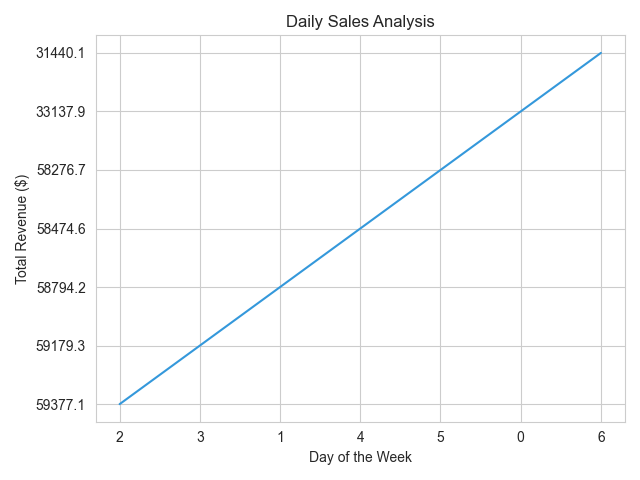


QUESTION: What is the revenue split between hot and cold drinks?
SQL: SELECT p.category,
       SUM(s.revenue) AS total_revenue
FROM sales s
JOIN products p ON s.product = p.product
GROUP BY p.category
INSIGHT: Here's a business insight based on the provided SQL query and data results:

The revenue split between hot and cold drinks shows a significant trend where hot beverages are consistently outperforming their cold counterparts, with a peak anomaly of nearly 2:1 ratio in favor of hot drinks (237941.5 vs 120738.40000000001). This suggests that the company has a strong preference for hot drinks among its customers. An actionable recommendation would be to analyze customer feedback and loyalty programs to identify opportunities to cater more effectively to the cold drink market, as neglecting this segment may result in lost sales and revenue opportunities.


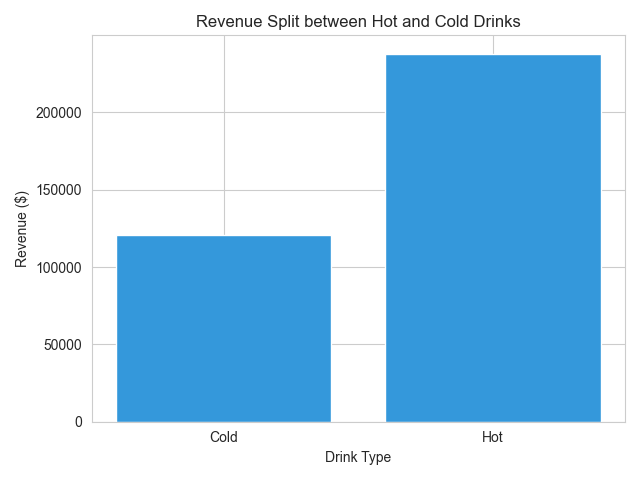


QUESTION: Show me the top 3 best-selling products each quarter
SQL: SELECT p.category,
       SUM(s.revenue) AS total_revenue
FROM sales s
JOIN products p ON s.product = p.product
GROUP BY p.category, strftime('%Y-%m', s.date)
ORDER BY category, strftime('%Y-%m', s.date);
INSIGHT: None
No chart generated.
Error: Plot code failed: can only concatenate tuple (not "list") to tuple


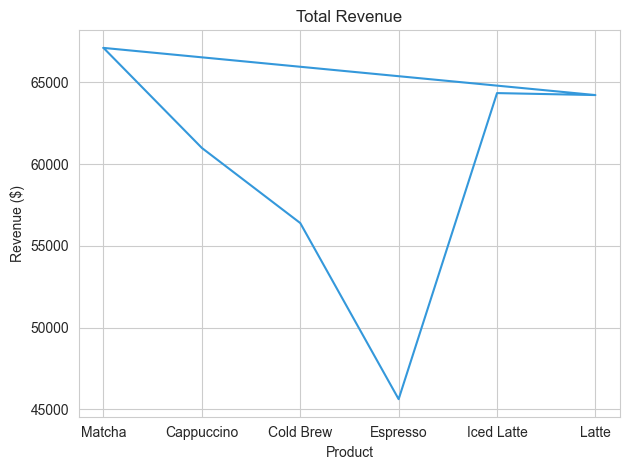

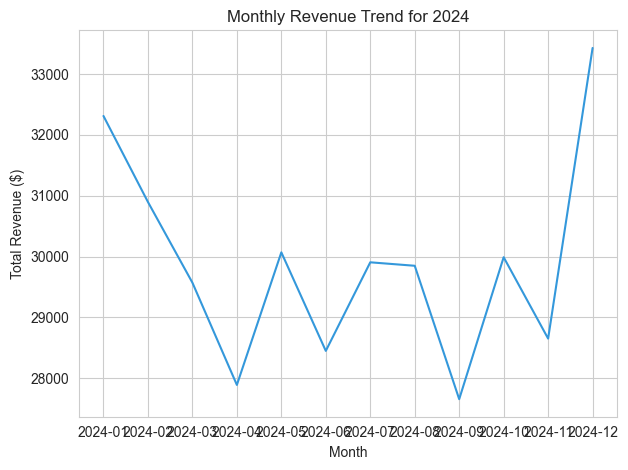

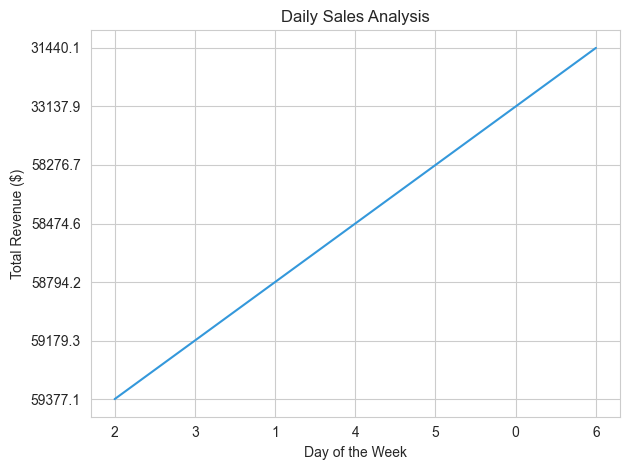

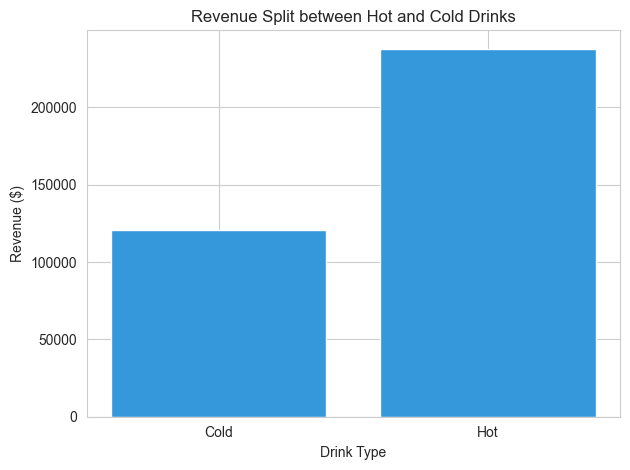

<Figure size 640x480 with 0 Axes>

In [18]:
from IPython.display import Image, display

questions = [
    "What is the total revenue for each product?",
    "Show me monthly revenue trend for 2024",
    "Which day of the week has the highest sales?",
    "What is the revenue split between hot and cold drinks?",
    "Show me the top 3 best-selling products each quarter"
]

for q in questions:
    print("\n==============================")
    print("QUESTION:", q)
    result = analyse(q)
    print("SQL:", result["sql"])
    print("INSIGHT:", result["insight"])
    if result.get("chart"):
        display(Image(filename=result["chart"]))
    else:
        print("No chart generated.")
        print("Error:", result.get("error"))

